# Livestock Numbers (1971-2019)

Exploring New Zealand livestock population data from 1971 to 2019.

In [12]:
import pandas as pd

livestock = pd.read_csv("livestock-numbers-clean-1971-2019.csv")
livestock

,geography_type,geography_name,year,animal,count
0,New Zealand,New Zealand,1971,Beef cattle,4796000.0
1,New Zealand,New Zealand,1972,Beef cattle,5344000.0
2,New Zealand,New Zealand,1973,Beef cattle,5765000.0
3,New Zealand,New Zealand,1974,Beef cattle,6237000.0
4,New Zealand,New Zealand,1975,Beef cattle,6294000.0
...,...,...,...,...,...
4615,Territorial Authority,Whangarei District,2012,Total cattle,220120.0
4616,Territorial Authority,Whangarei District,1994,Total cattle,254980.0
4617,Territorial Authority,Whangarei District,2002,Total cattle,256734.0
4618,Territorial Authority,Whangarei District,2007,Total cattle,241209.0


In [13]:
total_cattle_nz = (
    livestock
    .query("animal == 'Total cattle' and geography_type == 'New Zealand'")
    .dropna(subset=["count"])
)

total_cattle_nz

,geography_type,geography_name,year,animal,count
2356,New Zealand,New Zealand,1971,Total cattle,7995000.0
2357,New Zealand,New Zealand,1972,Total cattle,8632000.0
2358,New Zealand,New Zealand,1973,Total cattle,8924000.0
2359,New Zealand,New Zealand,1974,Total cattle,9311000.0
2360,New Zealand,New Zealand,1975,Total cattle,9292000.0
2361,New Zealand,New Zealand,1976,Total cattle,9017000.0
2362,New Zealand,New Zealand,1977,Total cattle,8739000.0
2363,New Zealand,New Zealand,1978,Total cattle,8418011.0
2364,New Zealand,New Zealand,1979,Total cattle,8022405.0
2365,New Zealand,New Zealand,1980,Total cattle,8131214.0


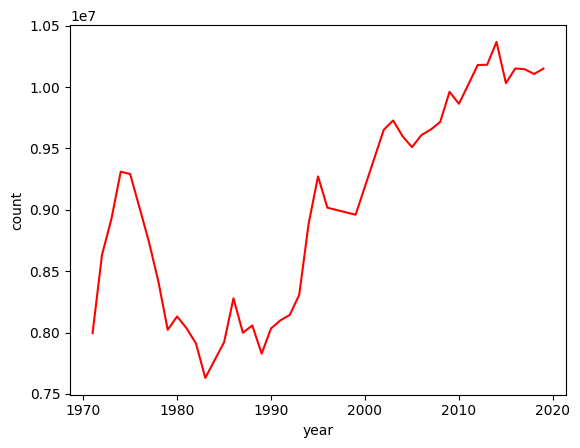

In [14]:
import matplotlib.pyplot as plt

plt.plot(total_cattle_nz["year"], total_cattle_nz["count"], color="red")
plt.xlabel("year")
plt.ylabel("count")
plt.show()


## Data Overview

In [19]:
animals = livestock["animal"].unique()
geography_types = livestock["geography_type"].unique()

print("Animals:", animals)
print("\nGeography types:", geography_types)

Animals: <StringArray>
['Beef cattle', 'Dairy cattle', 'Deer', 'Sheep', 'Total cattle']
Length: 5, dtype: str

Geography types: <StringArray>
['New Zealand', 'Region', 'Territorial Authority']
Length: 3, dtype: str


In [18]:
# National-level summary: latest year counts by animal
summary_stats = (
    livestock
    .query("geography_type == 'New Zealand'")
    .groupby("animal")["count"]
    .agg(["min", "max", "mean"])
    .rename(columns={"min": "Min", "max": "Max", "mean": "Mean"})
    .assign(**{c: lambda df, c=c: df[c].div(1e6).round(2) for c in ["Min", "Max", "Mean"]})
    .rename_axis("Animal")
    .add_suffix(" (millions)")
)

summary_stats

,Min (millions),Max (millions),Mean (millions)
Animal,,,
Beef cattle,3.53,6.29,4.66
Dairy cattle,2.90,6.70,4.35
Deer,0.04,1.76,0.94
Sheep,26.82,70.30,49.03
Total cattle,7.63,10.37,9.01


## National Trends Over Time

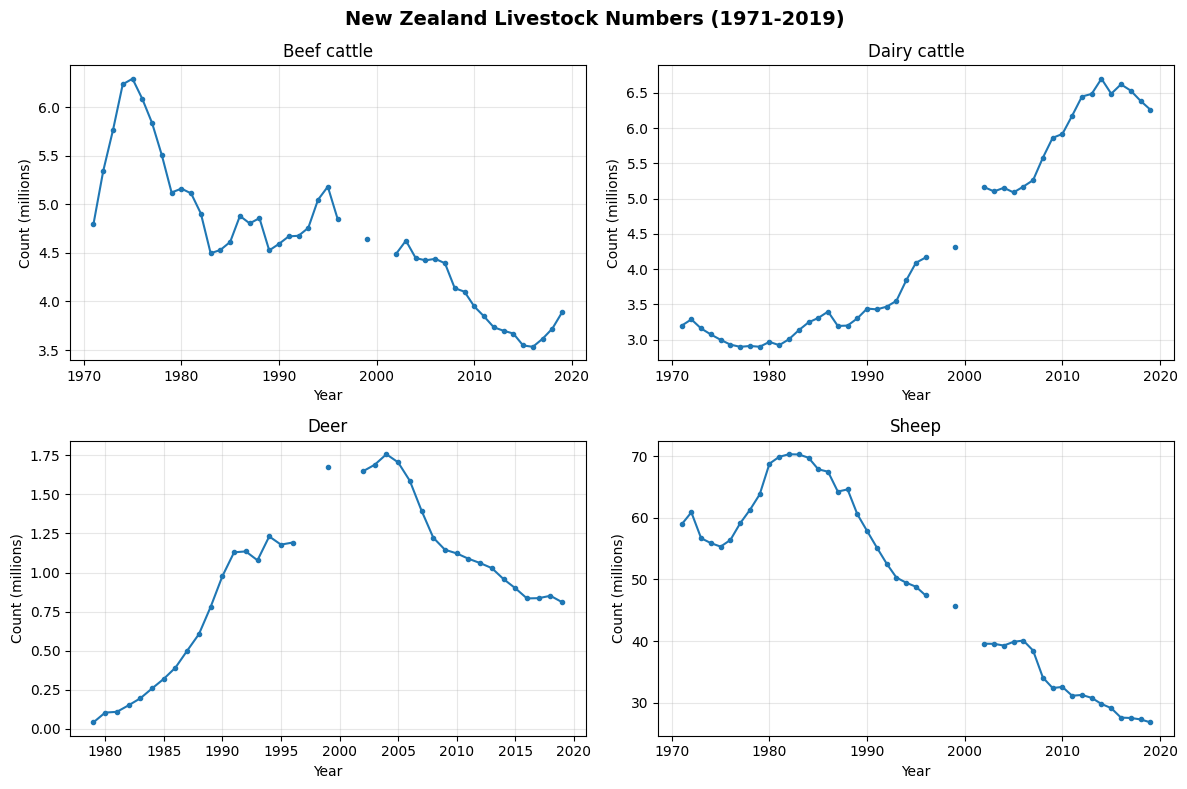

In [17]:
import matplotlib.pyplot as plt

nz = (
    livestock
    .query("geography_type == 'New Zealand' and animal != 'Total cattle'")
    .assign(count_millions=lambda df: df["count"] / 1e6)
)

animals = nz["animal"].unique()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, animal in zip(axes, animals):
    data = nz[nz["animal"] == animal]
    ax.plot(data["year"], data["count_millions"], marker="o", markersize=3, linewidth=1.5)
    ax.set_title(animal)
    ax.set_xlabel("Year")
    ax.set_ylabel("Count (millions)")
    ax.grid(True, alpha=0.3)

fig.suptitle("New Zealand Livestock Numbers (1971-2019)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()